# Decision Tree for Classification

Building a Decision Tree model to classify iris flowers 
into 3 species using the Iris dataset.

Tools: Python | Pandas | Scikit-learn | Matplotlib

## Step 1: Load and Preprocess Dataset
Loading the Iris dataset and encoding the target column (species)

No missing values found — dataset is clean and balanced (50 samples per class).

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("../../Data Set For Task/1) iris.csv")

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.shape

(150, 5)

In [5]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [7]:
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])
df['species'].value_counts()        

species
0    50
1    50
2    50
Name: count, dtype: int64

## Step 2: Train Test Split
Splitting into 80% training (120 samples) and 20% testing (30 samples).

In [8]:
x = df.drop(columns=["species"])
y = df['species']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(120, 4)
(30, 4)


## Step 3: Train Decision Tree (Unpruned)
Training a full Decision Tree with no depth limit (max_depth=None).
Tree grows until all leaves are pure (Gini = 0) which can cause overfitting.

In [9]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Step 4: Visualize Tree Structure
Visualizing the unpruned tree to understand how the model makes decisions.
Each node shows the split condition, Gini impurity, samples and class.

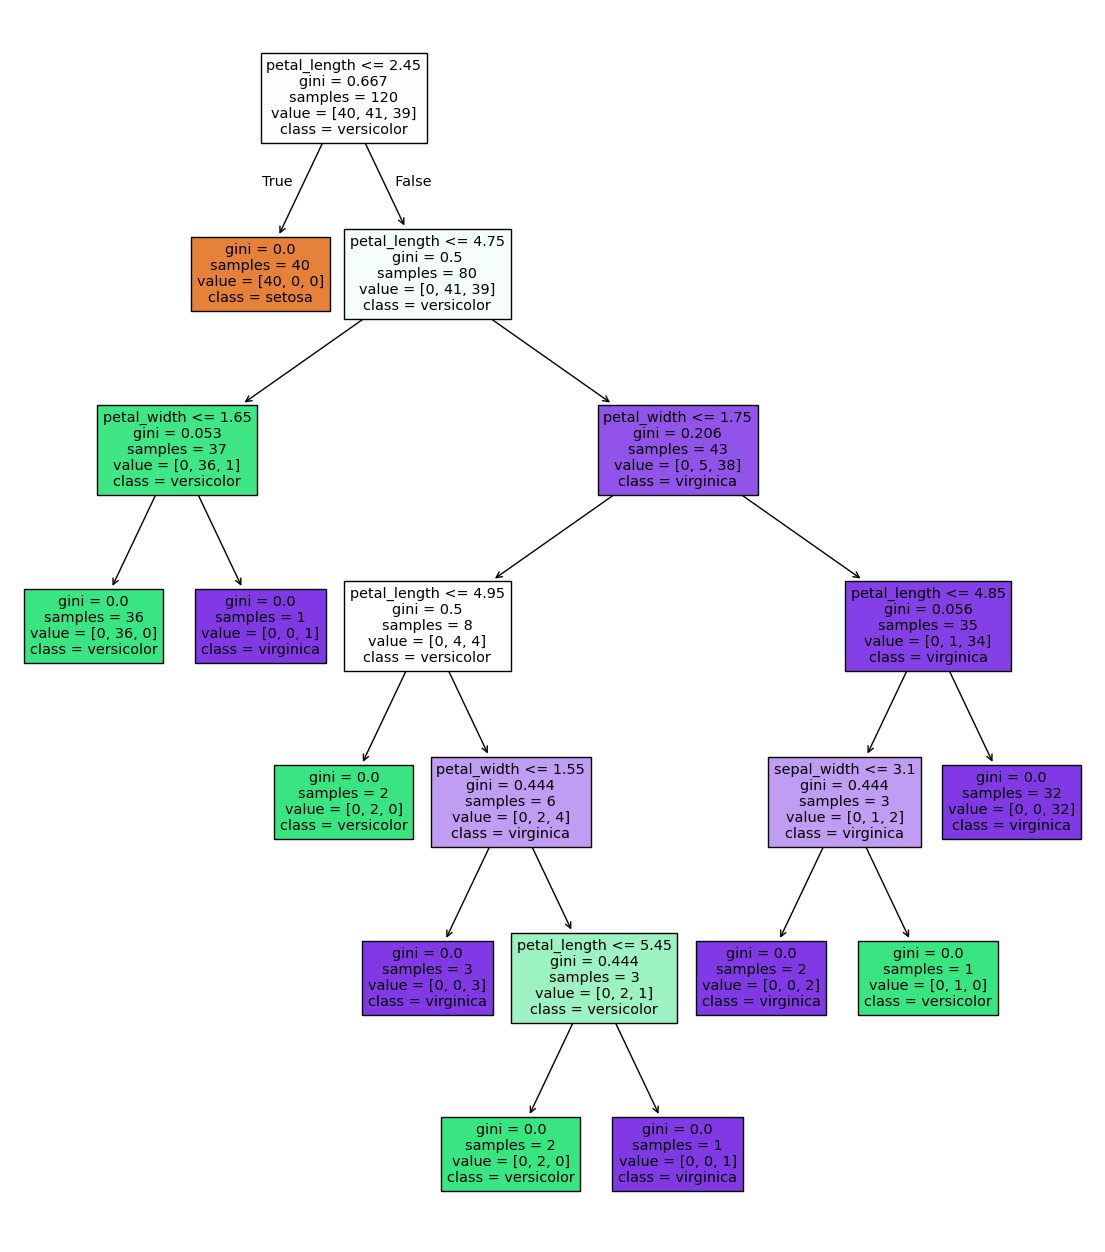

In [20]:
plt.figure(figsize=(14,16))
plot_tree(model, feature_names=x.columns,
          class_names= le.classes_,
          filled=True)
plt.show()

## Step 5: Pre-Pruning (max_depth=3)
Limiting tree depth to 3 levels to prevent overfitting.
Simpler tree that generalizes better on unseen data.

In [11]:
model_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
model_pruned.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


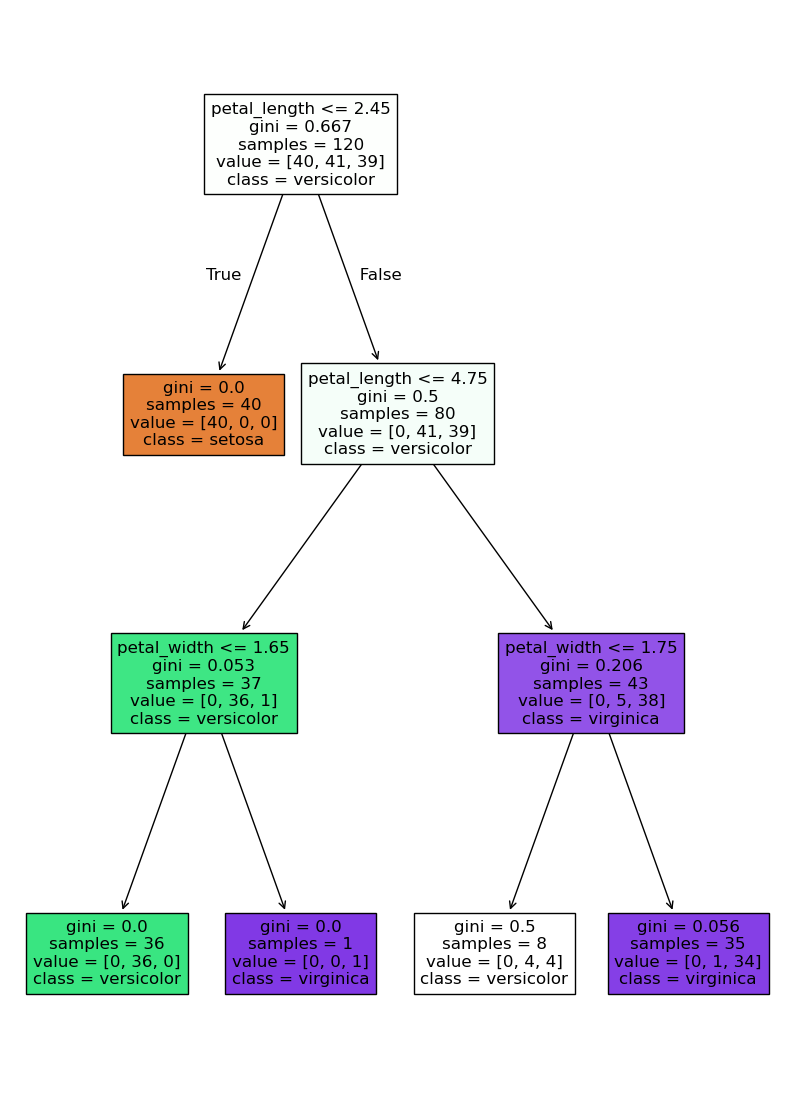

In [21]:
plt.figure(figsize=(10,14))
plot_tree(model_pruned,
          feature_names = x.columns,
          class_names = le.classes_,
          filled = True)

plt.show()

## Step 6: Post-Pruning (ccp_alpha)
Growing the full tree then finding the optimal alpha value
by plotting train vs test accuracy across all alpha values.

Higher alpha = more pruning = simpler tree.

In [13]:
path = model.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00809524 0.01111111 0.01111111 0.01621622 0.0241196
 0.24326537 0.33340278]


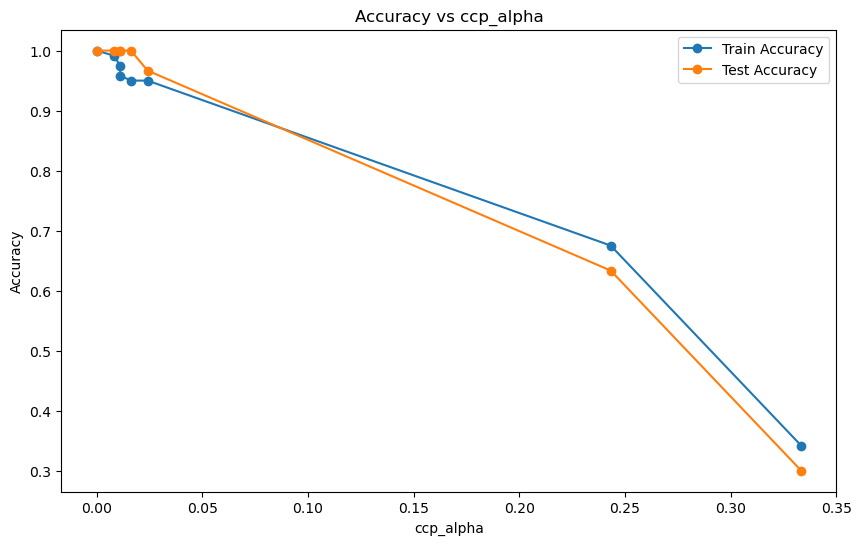

In [14]:
train_scores = []
test_scores = []

for alpha in ccp_alphas:
    model_alpha = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    model_alpha.fit(x_train, y_train)
    train_scores.append(model_alpha.score(x_train, y_train))
    test_scores.append(model_alpha.score(x_test, y_test))

plt.figure(figsize = (10,6))
plt.plot(ccp_alphas, train_scores, marker='o', label="Train Accuracy")
plt.plot(ccp_alphas, test_scores, marker='o', label="Test Accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs ccp_alpha")
plt.legend()
plt.show()

In [15]:
model_post_pruned = DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)
model_post_pruned.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


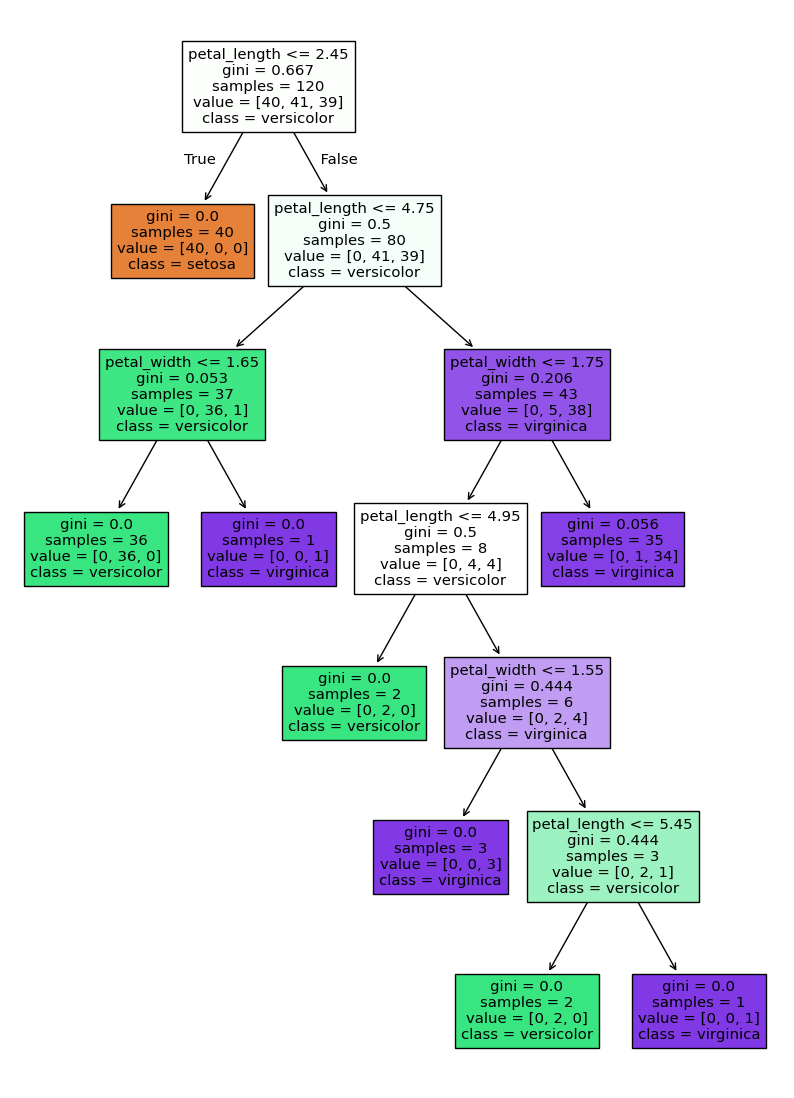

In [16]:
plt.figure(figsize=(10,14))
plot_tree(model_post_pruned, 
          feature_names= x.columns,
          class_names=le.classes_,
          filled = True)
plt.show()

## Step 7: Evaluate All Models
Comparing unpruned, pre-pruned and post-pruned models
using Accuracy and F1 Score (weighted for multi-class).
All models achieve 100% on Iris — dataset is too clean to show overfitting difference.
In real world datasets pruning would show a more significant improvement.

In [18]:
y_pred = model.predict(x_test)
y_pred_pruned = model_pruned.predict(x_test)
y_pred_post = model_post_pruned.predict(x_test)

print(f'Unpruned Accuracy: {model.score(x_test,y_test):.4f}')
print(f'Pre-Pruned Accuracy:   {model_pruned.score(x_test,y_test):.4f}')
print(f'Post-pruned Accuracy: {model_post_pruned.score(x_test,y_test):.4f}')

print(f'Unpruned F1:       {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'Pre-Pruned F1:         {f1_score(y_test, y_pred_pruned, average="weighted"):.4f}')
print(f'Post-pruned F1:       {f1_score(y_test, y_pred_post, average="weighted"):.4f}')

Unpruned Accuracy: 1.0000
Pre-Pruned Accuracy:   1.0000
Post-pruned Accuracy: 1.0000
Unpruned F1:       1.0000
Pre-Pruned F1:         1.0000
Post-pruned F1:       1.0000
